# Processed issues — EDA

In [1]:
import json
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/processed_issues.json")

records = json.loads(DATA_PATH.read_text())
df = pd.DataFrame(records)
df["created_at"] = pd.to_datetime(df["created_at"])
df["num_labels"] = df["labels"].apply(len)
df["word_count"] = df["text"].str.split().apply(len)

print(f"{len(df)} issues loaded")
df.head()

3494 issues loaded


,number,text,labels,created_at,num_labels,word_count
0,191481,Rename test/inductor/test_cudacodecache.py to ...,"[module: tests, triaged, oncall: pt2, module: ...",2026-07-29 11:46:43+00:00,5,211
1,191471,"Refactoring compile tests 🚀 The feature, motiv...","[feature, module: tests, triaged, oncall: pt2,...",2026-07-29 09:44:07+00:00,7,549
2,191469,[Inductor] 2D slice-update producer is fused i...,"[triage review, module: performance, module: r...",2026-07-29 09:17:37+00:00,6,126
3,191458,uint64 scalar assignment overflow 🐛 Describe t...,"[triaged, bot-triaged]",2026-07-29 07:55:47+00:00,2,112
4,191449,Incorrect compiled output when calling .resize...,"[triage review, module: correctness (silent), ...",2026-07-29 06:27:41+00:00,5,55


## Overview

In [2]:
n_issues = len(df)
n_unique_labels = len({label for labels in df["labels"] for label in labels})
date_min, date_max = df["created_at"].min(), df["created_at"].max()

print(f"Total issues: {n_issues}")
print(f"Unique labels: {n_unique_labels}")
print(f"Date range: {date_min.date()} to {date_max.date()} ({(date_max - date_min).days} days)")

Total issues: 3494
Unique labels: 25
Date range: 2025-12-27 to 2026-07-29 (214 days)


## Labels per issue

How many labels does a typical issue carry?

count    3494.000000
mean        3.703778
std         1.629636
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         9.000000
Name: num_labels, dtype: float64

Mean labels/issue:   3.70
Median labels/issue: 4.00


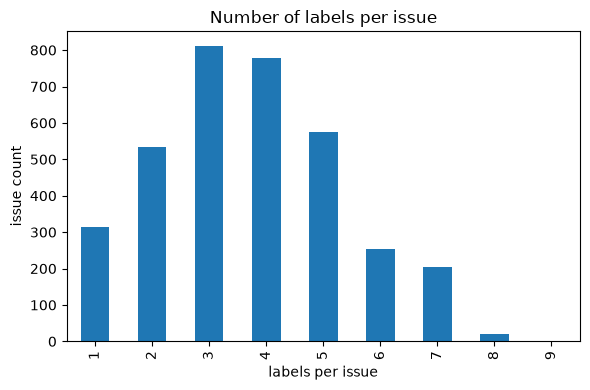

In [3]:
print(df["num_labels"].describe())
print(f"\nMean labels/issue:   {df['num_labels'].mean():.2f}")
print(f"Median labels/issue: {df['num_labels'].median():.2f}")

df["num_labels"].value_counts().sort_index().plot(
    kind="bar", figsize=(6, 4), title="Number of labels per issue"
)
plt.xlabel("labels per issue")
plt.ylabel("issue count")
plt.tight_layout()
plt.show()

## Label frequency

Which labels dominate, and how skewed is the distribution? This matters for the
classifier — very rare labels are hard to learn from.

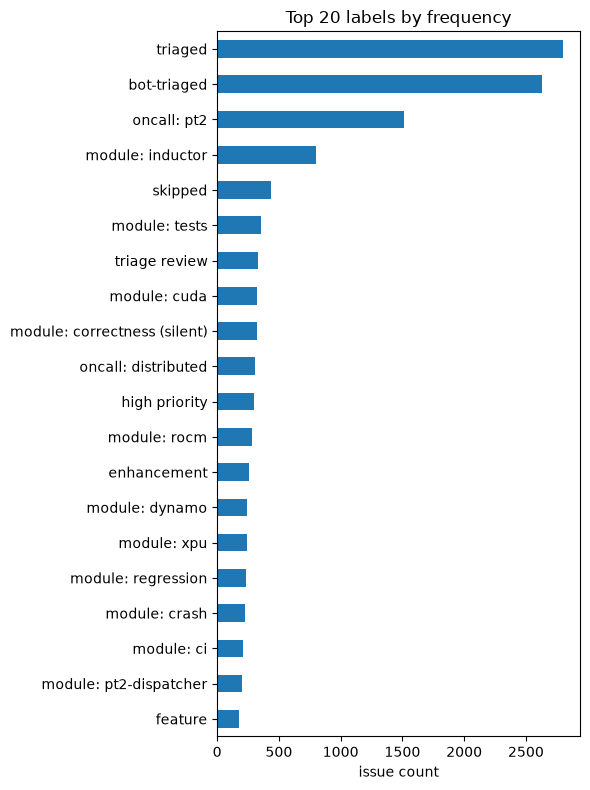

triaged                         2798
bot-triaged                     2631
oncall: pt2                     1514
module: inductor                 798
skipped                          434
module: tests                    356
triage review                    328
module: cuda                     320
module: correctness (silent)     319
oncall: distributed              305
high priority                    298
module: rocm                     281
enhancement                      258
module: dynamo                   239
module: xpu                      239
module: regression               237
module: crash                    229
module: ci                       207
module: pt2-dispatcher           204
feature                          177
dtype: int64

In [4]:
label_counts = Counter(label for labels in df["labels"] for label in labels)
top_labels = pd.Series(dict(label_counts.most_common(20)))

top_labels.plot(kind="barh", figsize=(6, 8), title="Top 20 labels by frequency")
plt.gca().invert_yaxis()
plt.xlabel("issue count")
plt.tight_layout()
plt.show()

top_labels

## Issue text length

Word count of title + cleaned body — informs TF-IDF vocabulary size choices.

count    3494.000000
mean      282.981110
std       351.385495
min         1.000000
25%        61.000000
50%       160.000000
75%       355.750000
max      4774.000000
Name: word_count, dtype: float64


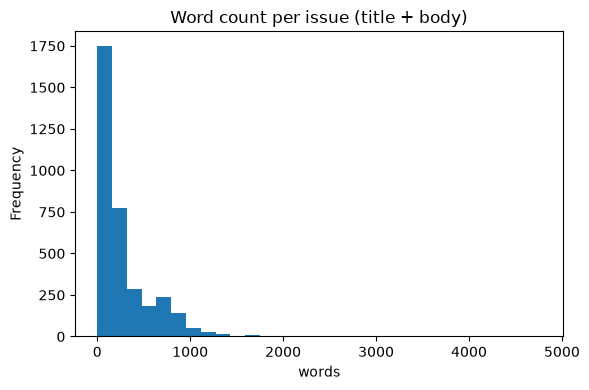

In [5]:
print(df["word_count"].describe())

df["word_count"].plot(kind="hist", bins=30, figsize=(6, 4), title="Word count per issue (title + body)")
plt.xlabel("words")
plt.tight_layout()
plt.show()

## Issues created over time

Shape of the sample in time — relevant since training uses a time-based split.

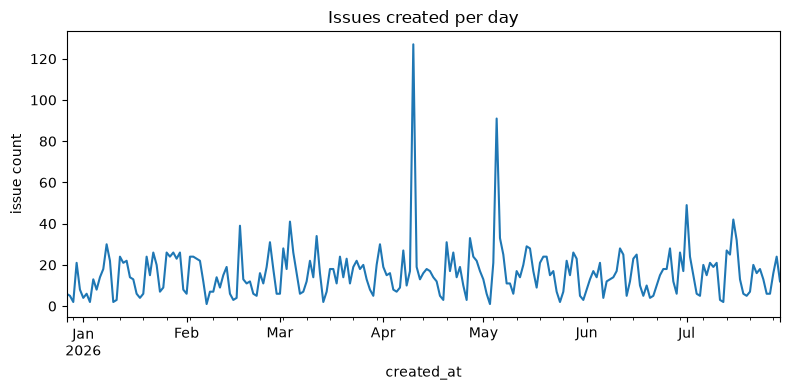

In [6]:
issues_per_day = df.set_index("created_at").resample("D").size()

issues_per_day.plot(figsize=(8, 4), title="Issues created per day")
plt.ylabel("issue count")
plt.tight_layout()
plt.show()

## Label co-occurrence (top 10 labels)

Which labels tend to show up together — useful context for a multi-label model
(e.g. does `bug` commonly co-occur with a component label?).

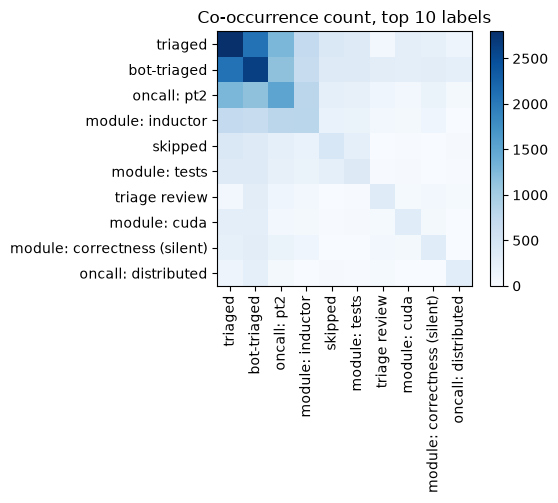

In [7]:
top_label_names = [label for label, _ in label_counts.most_common(10)]
cooc = pd.DataFrame(0, index=top_label_names, columns=top_label_names)

for labels in df["labels"]:
    present = [label for label in labels if label in top_label_names]
    for a in present:
        for b in present:
            cooc.loc[a, b] += 1

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cooc.values, cmap="Blues")
ax.set_xticks(range(len(top_label_names)))
ax.set_yticks(range(len(top_label_names)))
ax.set_xticklabels(top_label_names, rotation=90)
ax.set_yticklabels(top_label_names)
fig.colorbar(im)
plt.title("Co-occurrence count, top 10 labels")
plt.tight_layout()
plt.show()